> **Revision note.** Two profile labels in section 13 were corrected
> (`"Full-stack developer"` → `"Developer, full-stack"`, `"United States"` →
> `"United States of America"`); both were being dropped silently by the encoders, so the
> original section-13 numbers described a developer with no role and a US developer who
> was not recognised as American. A validation guard and an empirical cross-check of the
> growth rate were added. Cells whose output is affected have been cleared —
> **re-run the notebook from the top** to regenerate them.

# Salary Prediction from the Stack Overflow Developer Survey (2021–2025)

**University Data Science / Machine Learning project**

---

## 1. Project Overview

### Goal
Build a supervised regression model that predicts a developer's **annual salary in USD**
(`ConvertedCompYearly`) from a small set of profile attributes, and use it to estimate
salaries for future years.

### Data
A merged Stack Overflow Developer Survey file covering **2021–2025**
(~360,519 rows × 269 columns). Only a handful of columns are used here.

### Features used

| Feature | Type | Notes |
|---|---|---|
| `Country` | categorical | one-hot encoded |
| `YearsCode` | numeric (dirty) | contains `"Less than 1 year"` and `"More than 50 years"` |
| `DevType` | multi-label categorical | `;`-separated, multi-hot encoded |
| `LanguageHaveWorkedWith` | multi-label categorical | `;`-separated, multi-hot encoded |
| `Year` | numeric | kept numeric so the model can learn a time trend |

**Target:** `ConvertedCompYearly` (annual salary, USD).

### Validation strategy
**No random split.** The data is split **chronologically**:

* **Training set:** survey years **2021 – 2024**
* **Test set:** survey year **2025**

This mimics the real deployment situation (train on the past, predict the future) and
prevents any optimistic leakage from mixing years.

### Models
`RandomForestRegressor` and `XGBRegressor` (if `xgboost` is installed) are trained and
compared; the model with the **lowest MAE** on the 2025 test set is selected.

### Deliverables produced by this notebook

| File | Contents |
|---|---|
| `salary_predictor.pkl` | the **complete** fitted `Pipeline` (preprocessing + model) |
| `salary_utils.py` | the custom transformers the pipeline depends on |
| `metrics.txt` | selected model, MAE, RMSE, R² |
| `predict.py` | minimal example of loading the model and predicting |

> **Important design decision:** *every* preprocessing step lives inside a single
> `sklearn` `Pipeline` / `ColumnTransformer`. After loading the `.pkl` you can call
> `pipeline.predict(raw_dataframe)` on completely raw input — no manual cleaning needed.

---

### How to run

1. Set `CSV_PATH` in the configuration cell below to your merged CSV file.
2. Run all cells from top to bottom.

*Runtime note:* the Random Forest is the slow step (typically a few minutes on ~100k
rows). Lower `RF_N_ESTIMATORS` in the configuration cell if you need it faster.

## 2. Import Libraries

All third-party libraries used by the notebook are imported here. Library versions are
printed so the results are reproducible.

Requirements: `pandas`, `numpy`, `matplotlib`, `scikit-learn >= 1.1`, `joblib`,
and optionally `xgboost`.

In [1]:
# --- Standard library -------------------------------------------------------
import os
import sys
import json
import textwrap
import warnings
from collections import Counter

# --- Scientific stack -------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- scikit-learn -----------------------------------------------------------
import sklearn
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib

# --- Optional: XGBoost ------------------------------------------------------
try:
    from xgboost import XGBRegressor
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False

warnings.filterwarnings("ignore")

%matplotlib inline
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True

print("Python      :", sys.version.split()[0])
print("pandas      :", pd.__version__)
print("numpy       :", np.__version__)
print("scikit-learn:", sklearn.__version__)
print("xgboost     :", "available" if XGBOOST_AVAILABLE else "NOT installed (will be skipped)")

Python      : 3.11.0
pandas      : 3.0.3
numpy       : 2.2.6
scikit-learn: 1.8.0
xgboost     : available


### Configuration

Every tunable constant of the project is gathered in one place so that nothing has to be
edited further down in the notebook.

In [2]:
# ---------------------------------------------------------------------------
# CONFIGURATION — edit only this cell
# ---------------------------------------------------------------------------

# Path to the merged Stack Overflow survey CSV (2021-2025)
CSV_PATH = r"C:\Users\user\Desktop\term6\Data science\merged_results\merged_results.csv"


# Where the exported artifacts are written
OUTPUT_DIR = "."

# Chronological split
TRAIN_YEARS = [2021, 2022, 2023, 2024]
TEST_YEAR = 2025

# Future years to extrapolate to
FUTURE_YEARS = [2025, 2026, 2027, 2028]

# Plausible salary range (USD/year). Rows outside this range are treated as
# data-entry errors / extreme outliers and removed.
MIN_SALARY = 1_000
MAX_SALARY = 400_000

# Model hyper-parameters
RANDOM_STATE = 42
RF_N_ESTIMATORS = 300        # lower this (e.g. 100) if training is too slow
XGB_N_ESTIMATORS = 600

# Rare-category thresholds
COUNTRY_MIN_FREQUENCY = 50   # countries with fewer rows are grouped as "infrequent"
LABEL_MIN_FREQUENCY = 0.002  # DevType / language must appear in >= 0.2% of rows

os.makedirs(OUTPUT_DIR, exist_ok=True)
print("Artifacts will be written to:", os.path.abspath(OUTPUT_DIR))

Artifacts will be written to: c:\Users\user\Desktop\term6\Data science\merged_results


## 3. Load CSV Dataset

The raw file has 269 columns and uses roughly 740 MB of RAM when fully loaded. Since only
six columns are needed, the notebook:

1. reads **only the header** to inspect the full column list, then
2. re-reads the file with `usecols`, loading just the required columns.

This keeps memory usage low and avoids the mixed-dtype warnings produced by the wide file.

In [3]:
# Columns required by this project
FEATURES = ["Country", "YearsCode", "DevType", "LanguageHaveWorkedWith", "Year"]
TARGET = "ConvertedCompYearly"
REQUIRED_COLUMNS = FEATURES + [TARGET]

# Step 1 — read the header only, to inspect the full schema
all_columns = pd.read_csv(CSV_PATH, nrows=0).columns.tolist()
print(f"Total columns in the raw file: {len(all_columns)}")

missing_required = [c for c in REQUIRED_COLUMNS if c not in all_columns]
if missing_required:
    raise KeyError(f"These required columns are not in the CSV: {missing_required}")

print("All required columns are present:", REQUIRED_COLUMNS)

Total columns in the raw file: 269
All required columns are present: ['Country', 'YearsCode', 'DevType', 'LanguageHaveWorkedWith', 'Year', 'ConvertedCompYearly']


In [4]:
# Step 2 — load only the columns we actually need
df = pd.read_csv(
    CSV_PATH,
    usecols=REQUIRED_COLUMNS,
    low_memory=False,      # avoids the DtypeWarning on mixed-type columns
)

# Keep a consistent column order
df = df[REQUIRED_COLUMNS]

print("Loaded shape:", df.shape)
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1e6:,.1f} MB")

Loaded shape: (360519, 6)
Memory usage: 114.9 MB


## 4. Dataset Overview

A first look at the structure, dtypes and value ranges of the working dataset.

In [5]:
print("Shape:", df.shape)
print("\n--- First rows ---")
display(df.head(10))

Shape: (360519, 6)

--- First rows ---


,Country,YearsCode,DevType,LanguageHaveWorkedWith,Year,ConvertedCompYearly
0,Slovakia,NaN,"Developer, mobile",C++;HTML/CSS;JavaScript;Objective-C;PHP;Swift,2021,62268.0
1,Netherlands,7,NaN,JavaScript;Python,2021,NaN
2,Russian Federation,NaN,NaN,Assembly;C;Python;R;Rust,2021,NaN
3,Austria,NaN,"Developer, front-end",JavaScript;TypeScript,2021,NaN
4,United Kingdom of Great Britain and Northern I...,17,"Developer, desktop or enterprise applications;...",Bash/Shell;HTML/CSS;Python;SQL,2021,NaN
5,United States of America,NaN,NaN,C;C#;C++;HTML/CSS;Java;JavaScript;Node.js;Powe...,2021,NaN
6,United States of America,3,NaN,HTML/CSS;JavaScript,2021,NaN
7,Malaysia,4,NaN,HTML/CSS;JavaScript;PHP;Ruby;SQL;TypeScript,2021,NaN
8,India,6,"Developer, front-end",HTML/CSS;JavaScript,2021,NaN
9,Sweden,7,Data scientist or machine learning specialist,C++;Python,2021,51552.0


In [6]:
print("--- Dtypes and non-null counts ---")
df.info()

--- Dtypes and non-null counts ---
<class 'pandas.DataFrame'>
RangeIndex: 360519 entries, 0 to 360518
Data columns (total 6 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Country                 337550 non-null  str    
 1   YearsCode               343318 non-null  str    
 2   DevType                 307783 non-null  str    
 3   LanguageHaveWorkedWith  331888 non-null  str    
 4   Year                    360519 non-null  int64  
 5   ConvertedCompYearly     180316 non-null  float64
dtypes: float64(1), int64(1), str(4)
memory usage: 16.5 MB


In [7]:
print("--- Rows per survey year ---")
display(df["Year"].value_counts().sort_index().to_frame("rows"))

print("--- Target (ConvertedCompYearly) summary ---")
display(df[TARGET].describe().to_frame())

--- Rows per survey year ---


,rows
Year,
2021,83439
2022,73268
2023,89184
2024,65437
2025,49191


--- Target (ConvertedCompYearly) summary ---


,ConvertedCompYearly
count,1.803160e+05
mean,1.189899e+05
std,5.987161e+05
min,1.000000e+00
25%,3.514800e+04
50%,6.746600e+04
75%,1.150000e+05
max,7.435143e+07


In [8]:
# Cardinality of the categorical features
for col in ["Country", "DevType", "LanguageHaveWorkedWith", "YearsCode"]:
    print(f"{col:<25} unique raw values: {df[col].nunique():>7,}")

print("\nExample raw YearsCode values:")
print(df["YearsCode"].dropna().unique()[:15])

Country                   unique raw values:     196
DevType                   unique raw values:  17,898
LanguageHaveWorkedWith    unique raw values:  99,869
YearsCode                 unique raw values:     130

Example raw YearsCode values:
<StringArray>
[ '7', '17',  '3',  '4',  '6', '16', '12', '15', '10', '40',  '9', '26', '14',
 '39', '20']
Length: 15, dtype: str


## 5. Exploratory Data Analysis

The EDA is deliberately focused on the six selected columns. Its purpose is to justify the
cleaning decisions made in section 8, not to explore the whole survey.

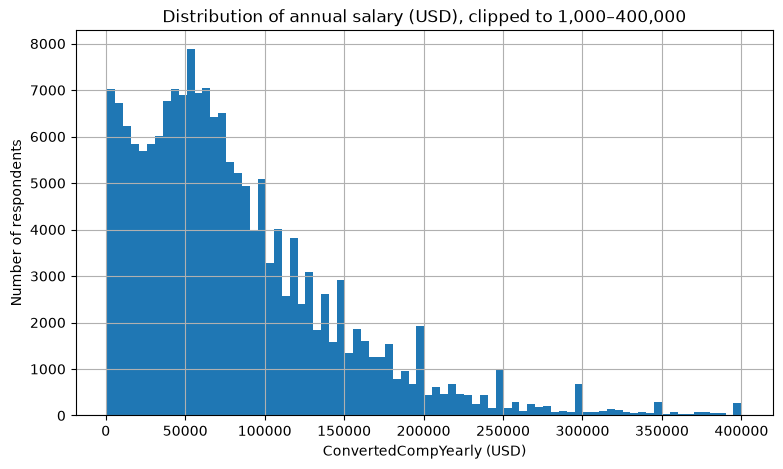

Reported salaries        : 180,316
Inside plausible range   : 173,613
Outside plausible range  : 6,703
Maximum reported value   : 74,351,432 USD  <- clearly an outlier


In [9]:
# Distribution of the target, restricted to a plausible range for readability
salary = df[TARGET].dropna()
salary_plot = salary[(salary >= MIN_SALARY) & (salary <= MAX_SALARY)]

plt.figure()
plt.hist(salary_plot, bins=80)
plt.title(f"Distribution of annual salary (USD), clipped to {MIN_SALARY:,}–{MAX_SALARY:,}")
plt.xlabel("ConvertedCompYearly (USD)")
plt.ylabel("Number of respondents")
plt.show()

print(f"Reported salaries        : {len(salary):,}")
print(f"Inside plausible range   : {len(salary_plot):,}")
print(f"Outside plausible range  : {len(salary) - len(salary_plot):,}")
print(f"Maximum reported value   : {salary.max():,.0f} USD  <- clearly an outlier")

The distribution is strongly **right-skewed** with a heavy tail of implausible values
(a handful of respondents report salaries in the millions or even billions). This confirms
that an explicit outlier filter is needed before training.

,median,mean,count
Year,,,
2021,54417.5,69144.611667,45170
2022,64486.0,81475.461042,35923
2023,74963.0,90336.216544,46882
2024,66162.0,80153.781480,22689
2025,75809.0,89573.357881,22949


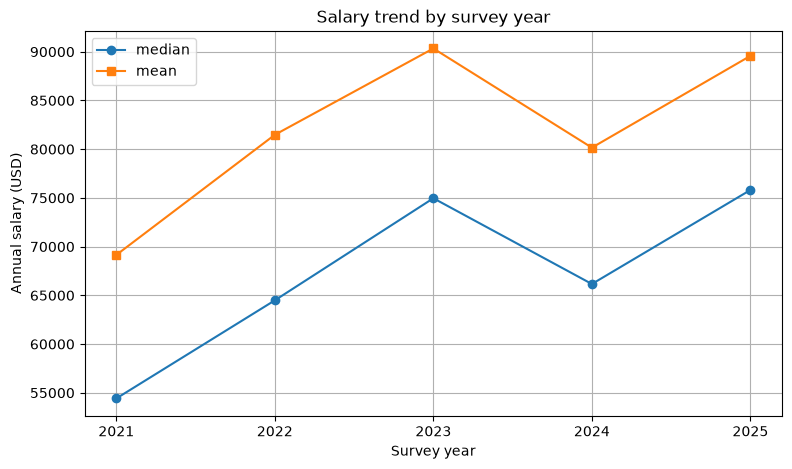

In [10]:
# Median salary per survey year — this is the time trend the model must learn
yearly = (
    df[df[TARGET].between(MIN_SALARY, MAX_SALARY)]
    .groupby("Year")[TARGET]
    .agg(["median", "mean", "count"])
)
display(yearly)

plt.figure()
plt.plot(yearly.index, yearly["median"], marker="o", label="median")
plt.plot(yearly.index, yearly["mean"], marker="s", label="mean")
plt.title("Salary trend by survey year")
plt.xlabel("Survey year")
plt.ylabel("Annual salary (USD)")
plt.xticks(yearly.index)
plt.legend()
plt.show()

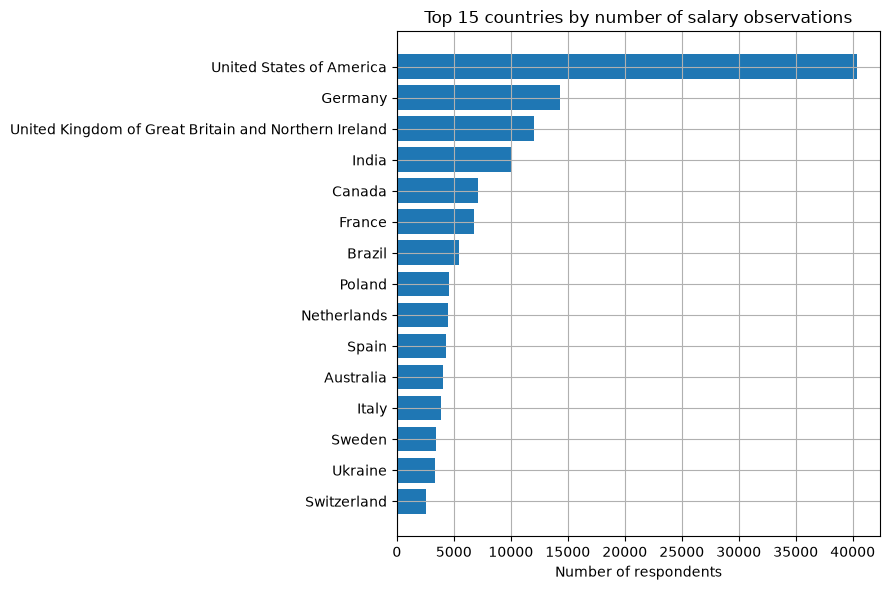

In [11]:
# Top 15 countries by number of respondents with a reported salary
top_countries = (
    df[df[TARGET].notna()]["Country"]
    .value_counts()
    .head(15)
    .sort_values()
)

plt.figure(figsize=(9, 6))
plt.barh(top_countries.index, top_countries.values)
plt.title("Top 15 countries by number of salary observations")
plt.xlabel("Number of respondents")
plt.tight_layout()
plt.show()

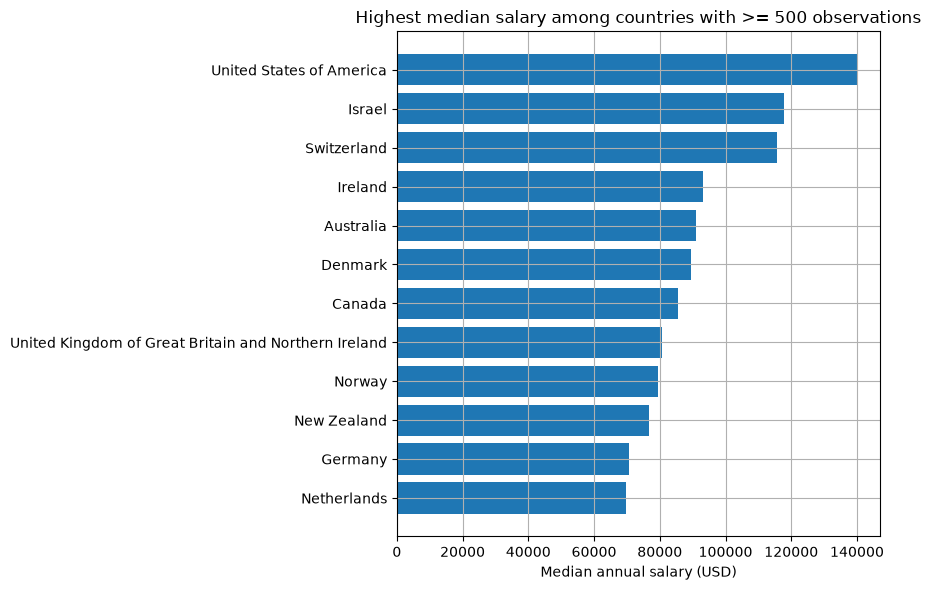

,median,count
Country,,
Netherlands,69608.0,4414
Germany,70722.5,13964
New Zealand,76668.0,1318
Norway,79552.0,1577
United Kingdom of Great Britain and Northern Ireland,80690.0,11440
Canada,85588.0,6906
Denmark,89472.0,1689
Australia,91013.0,3947
Ireland,93168.0,947


In [12]:
# Median salary for the 12 most frequent countries
country_stats = (
    df[df[TARGET].between(MIN_SALARY, MAX_SALARY)]
    .groupby("Country")[TARGET]
    .agg(["median", "count"])
    .query("count >= 500")
    .sort_values("median", ascending=False)
    .head(12)
    .sort_values("median")
)

plt.figure(figsize=(9, 6))
plt.barh(country_stats.index, country_stats["median"])
plt.title("Highest median salary among countries with >= 500 observations")
plt.xlabel("Median annual salary (USD)")
plt.tight_layout()
plt.show()

display(country_stats)

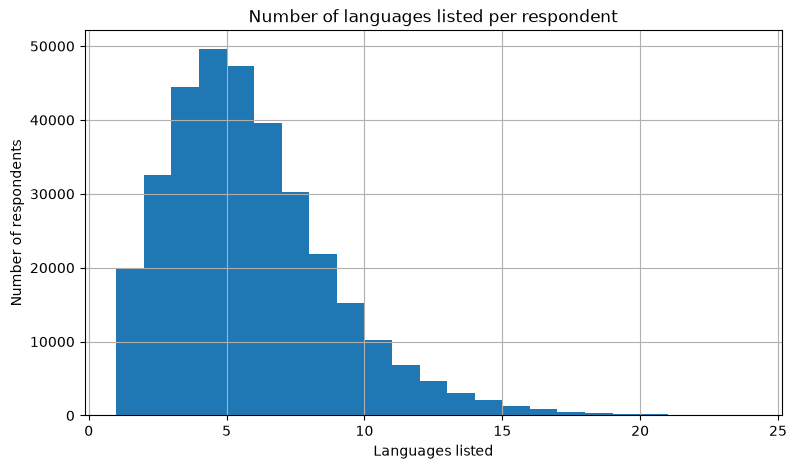

,respondents
JavaScript,214238
HTML/CSS,183311
Python,166234
SQL,165900
TypeScript,120711
Java,107160
C#,92230
C++,77027
C,67132
PHP,66176


In [13]:
# How many programming languages does a typical respondent list?
lang_counts = (
    df["LanguageHaveWorkedWith"]
    .dropna()
    .str.split(";")
    .apply(len)
)

plt.figure()
plt.hist(lang_counts, bins=range(1, 25))
plt.title("Number of languages listed per respondent")
plt.xlabel("Languages listed")
plt.ylabel("Number of respondents")
plt.show()

# 15 most common individual languages
flat_langs = Counter()
for value in df["LanguageHaveWorkedWith"].dropna():
    flat_langs.update(t.strip() for t in value.split(";") if t.strip())

display(pd.Series(dict(flat_langs.most_common(15)), name="respondents").to_frame())

`LanguageHaveWorkedWith` (and often `DevType`) contain **multiple `;`-separated values per
row**. Treating the whole string as one category would create tens of thousands of
near-unique categories, so section 9 uses a **multi-hot encoder** instead: one binary
column per individual label. This is the natural generalisation of one-hot encoding to
multi-label fields.

## 6. Missing Value Analysis

Missing values are examined **before** deciding how the pipeline should impute them.

,missing,missing_%,dtype
ConvertedCompYearly,180203,49.98,float64
DevType,52736,14.63,str
LanguageHaveWorkedWith,28631,7.94,str
Country,22969,6.37,str
YearsCode,17201,4.77,str
Year,0,0.00,int64


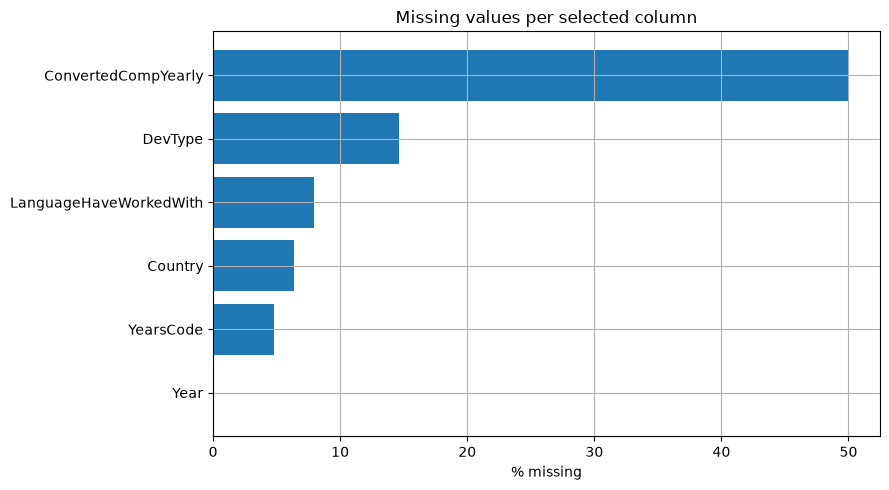

In [14]:
missing = pd.DataFrame({
    "missing": df.isna().sum(),
    "missing_%": (df.isna().mean() * 100).round(2),
    "dtype": df.dtypes.astype(str),
})
display(missing.sort_values("missing_%", ascending=False))

plt.figure()
plot_data = missing.sort_values("missing_%")
plt.barh(plot_data.index, plot_data["missing_%"])
plt.title("Missing values per selected column")
plt.xlabel("% missing")
plt.tight_layout()
plt.show()

### Missing-value strategy

| Column | Strategy | Where it happens |
|---|---|---|
| `ConvertedCompYearly` (target) | **rows dropped** — a target cannot be imputed | section 8 (outside the pipeline) |
| `Country` | imputed with the constant `"Unknown"` | **inside** the pipeline |
| `YearsCode` | parsed to numeric, then **median** imputation | **inside** the pipeline |
| `DevType` | missing → empty label set (all multi-hot columns are 0) | **inside** the pipeline |
| `LanguageHaveWorkedWith` | missing → empty label set | **inside** the pipeline |
| `Year` | median imputation (in practice never missing) | **inside** the pipeline |

Only the target rows are dropped outside the pipeline. Every feature-level imputation is
part of the saved model, which is what makes `pipeline.predict(raw_df)` safe on
incomplete user input.

## 7. Feature Selection

The project specification fixes the feature set, so no automatic selection is performed.
The chosen columns cover four complementary signals:

* **Where** the developer works — `Country` (by far the strongest salary driver)
* **How experienced** they are — `YearsCode`
* **What they do** — `DevType`
* **What they use** — `LanguageHaveWorkedWith`
* **When** the observation was made — `Year` (carries the time trend)

In [15]:
CATEGORICAL_SINGLE = ["Country"]                                   # one value per row
CATEGORICAL_MULTI  = ["DevType", "LanguageHaveWorkedWith"]         # ";"-separated lists
NUMERIC_DIRTY      = ["YearsCode"]                                 # numeric but text-encoded
NUMERIC_CLEAN      = ["Year"]

print("Features:", FEATURES)
print("Target  :", TARGET)

data = df[REQUIRED_COLUMNS].copy()
print("Working dataset:", data.shape)

Features: ['Country', 'YearsCode', 'DevType', 'LanguageHaveWorkedWith', 'Year']
Target  : ConvertedCompYearly
Working dataset: (360519, 6)


## 8. Data Cleaning

Only the operations that **cannot** live inside the pipeline are done here:

1. **Drop rows with a missing target.** The model has nothing to learn from them.
2. **Remove implausible salaries** (outside `MIN_SALARY`–`MAX_SALARY`). The EDA showed
   values in the billions, which would otherwise dominate the squared-error terms.
3. **Coerce `Year` to a proper integer** and drop the (very few) rows where it is missing.

Everything else — parsing `YearsCode`, imputing, encoding — is deferred to the pipeline so
that the saved model can handle raw input.

In [16]:
before = len(data)

# 1) rows without a target are unusable
data = data[data[TARGET].notna()].copy()
after_target = len(data)

# 2) remove implausible salaries
data = data[data[TARGET].between(MIN_SALARY, MAX_SALARY)].copy()
after_outliers = len(data)

# 3) Year must be a usable integer
data["Year"] = pd.to_numeric(data["Year"], errors="coerce")
data = data[data["Year"].notna()].copy()
data["Year"] = data["Year"].astype(int)
after_year = len(data)

print(f"Rows initially              : {before:>10,}")
print(f"After dropping missing target: {after_target:>10,}  (-{before - after_target:,})")
print(f"After removing outliers      : {after_outliers:>10,}  (-{after_target - after_outliers:,})")
print(f"After validating Year        : {after_year:>10,}  (-{after_outliers - after_year:,})")
print(f"\nFinal modelling dataset     : {data.shape}")

display(data[TARGET].describe().to_frame())

Rows initially              :    360,519
After dropping missing target:    180,316  (-180,203)
After removing outliers      :    173,613  (-6,703)
After validating Year        :    173,613  (-0)

Final modelling dataset     : (173613, 6)


,ConvertedCompYearly
count,173613.000000
mean,81557.692903
std,64394.964570
min,1000.000000
25%,35982.000000
50%,66716.000000
75%,110000.000000
max,400000.000000


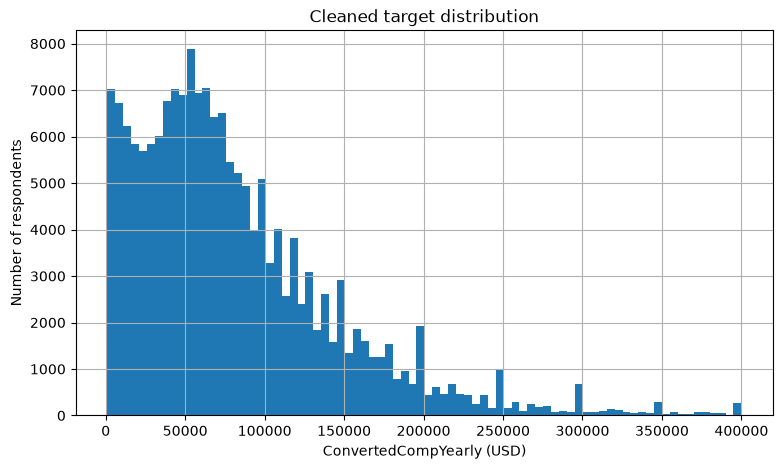

,count,median,mean
Year,,,
2021,45170,54417.5,69144.611667
2022,35923,64486.0,81475.461042
2023,46882,74963.0,90336.216544
2024,22689,66162.0,80153.781480
2025,22949,75809.0,89573.357881


In [17]:
# Sanity check: the cleaned target distribution
plt.figure()
plt.hist(data[TARGET], bins=80)
plt.title("Cleaned target distribution")
plt.xlabel("ConvertedCompYearly (USD)")
plt.ylabel("Number of respondents")
plt.show()

display(data.groupby("Year")[TARGET].agg(["count", "median", "mean"]))

## 9. Pipeline Construction

### Why the custom transformers live in a separate module

`joblib`/`pickle` stores functions and classes **by reference**, not by value. A helper
defined directly in the notebook would be recorded as living in `__main__`, and
`joblib.load()` inside `predict.py` would then fail with `AttributeError`.

The fix is standard practice: write the helpers to a real module, `salary_utils.py`, and
import them. The pickle then references `salary_utils.<name>`, which resolves correctly
anywhere the module is on the path.

> Ship `salary_utils.py` **next to** `salary_predictor.pkl`.

The cell below generates that module.

In [18]:
SALARY_UTILS_SOURCE = '''"""
salary_utils.py
===============
Custom transformers and helpers used by the salary-prediction pipeline.

This module is imported by the training notebook AND must be importable wherever
``salary_predictor.pkl`` is loaded, because pickle stores classes and functions by
reference.
"""

from collections import Counter

import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.preprocessing import OneHotEncoder


# ---------------------------------------------------------------------------
# YearsCode parsing
# ---------------------------------------------------------------------------
def parse_years_value(value):
    """Convert a single raw ``YearsCode`` entry into a float.

    Rules
    -----
    * ``"Less than 1 year"``  -> 0.5
    * ``"More than 50 years"`` -> 50.0
    * numeric strings          -> float
    * anything else / missing  -> NaN (imputed later in the pipeline)
    """
    if value is None:
        return np.nan
    if isinstance(value, (int, float, np.integer, np.floating)):
        return np.nan if pd.isna(value) else float(value)

    text = str(value).strip().lower()
    if text in ("", "nan", "none", "na"):
        return np.nan
    if text.startswith("less than"):
        return 0.5
    if text.startswith("more than"):
        return 50.0
    try:
        return float(text)
    except ValueError:
        return np.nan


def parse_years_code(X):
    """Vectorised version of :func:`parse_years_value` for a DataFrame/array column."""
    frame = pd.DataFrame(X).copy()
    for column in frame.columns:
        frame[column] = frame[column].map(parse_years_value)
    return frame.astype(float)


# ---------------------------------------------------------------------------
# Multi-hot encoder for ";"-separated multi-label columns
# ---------------------------------------------------------------------------
class MultiLabelEncoder(BaseEstimator, TransformerMixin):
    """One binary column per individual label of a ``;``-separated text column.

    This is the multi-label generalisation of one-hot encoding. Labels seen at
    prediction time but not during ``fit`` are ignored, and missing values are
    treated as an empty label set (all output columns equal 0).

    Parameters
    ----------
    separator : str
        Character separating the labels inside one cell.
    min_frequency : float or int
        Labels rarer than this are dropped. A value < 1 is read as a fraction of
        the training rows, a value >= 1 as an absolute row count.
    prefix : str
        Prefix used when building output feature names.
    """

    def __init__(self, separator=";", min_frequency=0.002, prefix="label"):
        self.separator = separator
        self.min_frequency = min_frequency
        self.prefix = prefix

    # -- helpers ------------------------------------------------------------
    def _to_series(self, X):
        if isinstance(X, pd.DataFrame):
            return X.iloc[:, 0]
        if isinstance(X, pd.Series):
            return X
        array = np.asarray(X)
        if array.ndim == 2:
            array = array[:, 0]
        return pd.Series(array)

    def _split(self, value):
        if value is None or (isinstance(value, float) and np.isnan(value)):
            return set()
        text = str(value)
        if text.strip().lower() in ("", "nan", "none"):
            return set()
        return {part.strip() for part in text.split(self.separator) if part.strip()}

    # -- scikit-learn API ---------------------------------------------------
    def fit(self, X, y=None):
        series = self._to_series(X)
        counts = Counter()
        for value in series:
            counts.update(self._split(value))

        n_rows = max(len(series), 1)
        if self.min_frequency < 1:
            threshold = max(1, int(self.min_frequency * n_rows))
        else:
            threshold = int(self.min_frequency)

        self.classes_ = sorted(label for label, count in counts.items() if count >= threshold)
        self.class_to_index_ = {label: i for i, label in enumerate(self.classes_)}
        self.n_features_out_ = len(self.classes_)
        return self

    def transform(self, X):
        series = self._to_series(X)
        out = np.zeros((len(series), self.n_features_out_), dtype=np.float64)
        for row, value in enumerate(series):
            for label in self._split(value):
                index = self.class_to_index_.get(label)
                if index is not None:
                    out[row, index] = 1.0
        return out

    def get_feature_names_out(self, input_features=None):
        return np.array([f"{self.prefix}__{label}" for label in self.classes_], dtype=object)


# ---------------------------------------------------------------------------
# Version-tolerant OneHotEncoder factory
# ---------------------------------------------------------------------------
def make_one_hot_encoder(min_frequency=50):
    """Return a dense OneHotEncoder that tolerates unseen categories.

    Falls back gracefully on scikit-learn versions that do not support the
    ``sparse_output`` / ``min_frequency`` arguments.
    """
    try:
        return OneHotEncoder(
            handle_unknown="infrequent_if_exist",
            min_frequency=min_frequency,
            sparse_output=False,
        )
    except TypeError:
        pass
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)
'''

utils_path = os.path.join(OUTPUT_DIR, "salary_utils.py")
with open(utils_path, "w", encoding="utf-8") as handle:
    handle.write(SALARY_UTILS_SOURCE)

print("Written:", os.path.abspath(utils_path))

Written: c:\Users\user\Desktop\term6\Data science\merged_results\salary_utils.py


In [19]:
# Make the freshly written module importable from this notebook
import importlib
if OUTPUT_DIR not in sys.path:
    sys.path.insert(0, OUTPUT_DIR)

import salary_utils
importlib.reload(salary_utils)

# Quick smoke test of the YearsCode parser
examples = ["Less than 1 year", "More than 50 years", "5", "12", 25, None, np.nan, "weird"]
for raw in examples:
    print(f"{str(raw):<20} -> {salary_utils.parse_years_value(raw)}")

Less than 1 year     -> 0.5
More than 50 years   -> 50.0
5                    -> 5.0
12                   -> 12.0
25                   -> 25.0
None                 -> nan
nan                  -> nan
weird                -> nan


### The `ColumnTransformer`

| Block | Columns | Steps |
|---|---|---|
| `country` | `Country` | constant imputation (`"Unknown"`) → one-hot encoding |
| `devtype` | `DevType` | multi-hot encoding |
| `language` | `LanguageHaveWorkedWith` | multi-hot encoding |
| `years_code` | `YearsCode` | text → numeric parsing → median imputation |
| `year` | `Year` | median imputation, **kept numeric** |

`Year` is deliberately **not** one-hot encoded. A one-hot `Year` would map any unseen year
(2026, 2027, …) to an all-zero vector, making future prediction meaningless. Keeping it as
a single numeric column lets the model use it as an ordered time axis.

In [20]:
# --- Country: impute then one-hot ------------------------------------------
country_transformer = Pipeline(steps=[
    ("impute", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("onehot", salary_utils.make_one_hot_encoder(min_frequency=COUNTRY_MIN_FREQUENCY)),
])

# --- YearsCode: parse text -> numeric, then impute the median ---------------
try:
    years_parser = FunctionTransformer(
        salary_utils.parse_years_code,
        feature_names_out="one-to-one",
        validate=False,
    )
except TypeError:  # scikit-learn < 1.1
    years_parser = FunctionTransformer(salary_utils.parse_years_code, validate=False)

years_code_transformer = Pipeline(steps=[
    ("parse", years_parser),
    ("impute", SimpleImputer(strategy="median")),
])

# --- The full preprocessor --------------------------------------------------
preprocessor = ColumnTransformer(
    transformers=[
        ("country", country_transformer, ["Country"]),
        ("devtype", salary_utils.MultiLabelEncoder(
            min_frequency=LABEL_MIN_FREQUENCY, prefix="devtype"), ["DevType"]),
        ("language", salary_utils.MultiLabelEncoder(
            min_frequency=LABEL_MIN_FREQUENCY, prefix="lang"), ["LanguageHaveWorkedWith"]),
        ("years_code", years_code_transformer, ["YearsCode"]),
        ("year", SimpleImputer(strategy="median"), ["Year"]),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('country', ...), ('devtype', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_n

### Chronological train / test split

The split is done on the **`Year` column**, not randomly: the model is trained on
2021–2024 and evaluated on the unseen 2025 responses.

In [21]:
train_mask = data["Year"].isin(TRAIN_YEARS)
test_mask = data["Year"] == TEST_YEAR

X_train = data.loc[train_mask, FEATURES].reset_index(drop=True)
y_train = data.loc[train_mask, TARGET].reset_index(drop=True)

X_test = data.loc[test_mask, FEATURES].reset_index(drop=True)
y_test = data.loc[test_mask, TARGET].reset_index(drop=True)

if len(X_train) == 0:
    raise ValueError(f"No training rows found for years {TRAIN_YEARS}.")
if len(X_test) == 0:
    raise ValueError(f"No test rows found for year {TEST_YEAR}.")

print(f"Training set ({'-'.join(map(str, [min(TRAIN_YEARS), max(TRAIN_YEARS)]))}): {X_train.shape}")
print(f"Test set     ({TEST_YEAR})                : {X_test.shape}")
print(f"\nTrain median salary: {y_train.median():>10,.0f} USD")
print(f"Test  median salary: {y_test.median():>10,.0f} USD")

display(data.loc[train_mask, "Year"].value_counts().sort_index().to_frame("training rows"))

Training set (2021-2024): (150664, 5)
Test set     (2025)                : (22949, 5)

Train median salary:     64,860 USD
Test  median salary:     75,809 USD


,training rows
Year,
2021,45170
2022,35923
2023,46882
2024,22689


In [22]:
# Inspect the design matrix the models will actually see
preprocessor.fit(X_train, y_train)
feature_names = preprocessor.get_feature_names_out()

print(f"Number of engineered features: {len(feature_names)}")
print("\nFirst 25 feature names:")
print(list(feature_names[:25]))
print("\nLast 10 feature names:")
print(list(feature_names[-10:]))

Number of engineered features: 190

First 25 feature names:
['Country_Albania', 'Country_Algeria', 'Country_Argentina', 'Country_Armenia', 'Country_Australia', 'Country_Austria', 'Country_Azerbaijan', 'Country_Bangladesh', 'Country_Belarus', 'Country_Belgium', 'Country_Bolivia', 'Country_Bosnia and Herzegovina', 'Country_Brazil', 'Country_Bulgaria', 'Country_Canada', 'Country_Chile', 'Country_China', 'Country_Colombia', 'Country_Costa Rica', 'Country_Croatia', 'Country_Cuba', 'Country_Cyprus', 'Country_Czech Republic', 'Country_Denmark', 'Country_Dominican Republic']

Last 10 feature names:
['lang__SQL', 'lang__Scala', 'lang__Solidity', 'lang__Swift', 'lang__TypeScript', 'lang__VBA', 'lang__Visual Basic (.Net)', 'lang__Zig', 'YearsCode', 'Year']


## 10. Model Training

Each model is wrapped in its **own complete pipeline** (`preprocessor` + estimator), so the
preprocessing is refitted on the training folds with the estimator and never leaks test
information.

> The Random Forest is the slowest cell in the notebook. Reduce `RF_N_ESTIMATORS` in the
> configuration cell if needed.

In [23]:
%%time
# --- Model 1: Random Forest -------------------------------------------------
# clone() gives this pipeline its own independent copy of the preprocessor
rf_pipeline = Pipeline(steps=[
    ("preprocessor", clone(preprocessor)),
    ("model", RandomForestRegressor(
        n_estimators=RF_N_ESTIMATORS,
        max_features="sqrt",     # keeps training tractable with ~300 encoded features
        min_samples_leaf=5,      # mild regularisation, smaller trees
        n_jobs=-1,
        random_state=RANDOM_STATE,
    )),
])

rf_pipeline.fit(X_train, y_train)
print("Random Forest trained.")

Random Forest trained.
CPU times: total: 3min 48s
Wall time: 18.2 s


In [24]:
%%time
# --- Model 2: XGBoost (only if the library is installed) --------------------
xgb_pipeline = None

if XGBOOST_AVAILABLE:
    xgb_pipeline = Pipeline(steps=[
        ("preprocessor", clone(preprocessor)),
        ("model", XGBRegressor(
            n_estimators=XGB_N_ESTIMATORS,
            learning_rate=0.05,
            max_depth=8,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_lambda=1.0,
            objective="reg:squarederror",
            tree_method="hist",
            n_jobs=-1,
            random_state=RANDOM_STATE,
        )),
    ])
    xgb_pipeline.fit(X_train, y_train)
    print("XGBoost trained.")
else:
    print("xgboost is not installed - this model is skipped.")
    print("Install it with:  pip install xgboost")

XGBoost trained.
CPU times: total: 1min 19s
Wall time: 8.7 s


## 11. Model Comparison

Both models are scored on the **2025 test set**. A naive baseline (always predicting the
median training salary) is included so the improvement can be judged in context.

The selection criterion is **MAE**, which is robust to the remaining right-skew of the
salary distribution and is directly interpretable in dollars.

In [25]:
def evaluate(name, y_true, y_pred):
    """Return MAE / RMSE / R2 for one model as a dictionary."""
    return {
        "Model": name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "R2": r2_score(y_true, y_pred),
    }


results = []
predictions = {}

# Baseline: constant prediction = median of the training target
baseline_pred = np.full(len(y_test), y_train.median())
results.append(evaluate("Baseline (train median)", y_test, baseline_pred))

# Random Forest
rf_pred = rf_pipeline.predict(X_test)
predictions["RandomForest"] = rf_pred
results.append(evaluate("RandomForest", y_test, rf_pred))

# XGBoost
if xgb_pipeline is not None:
    xgb_pred = xgb_pipeline.predict(X_test)
    predictions["XGBoost"] = xgb_pred
    results.append(evaluate("XGBoost", y_test, xgb_pred))

results_df = pd.DataFrame(results).set_index("Model").round(2)
display(results_df)

,MAE,RMSE,R2
Model,,,
Baseline (train median),51308.64,72011.35,-0.13
RandomForest,32727.42,47854.50,0.50
XGBoost,30521.21,45920.98,0.54


Selected model: XGBoost  (lowest MAE = 30,521.21 USD)


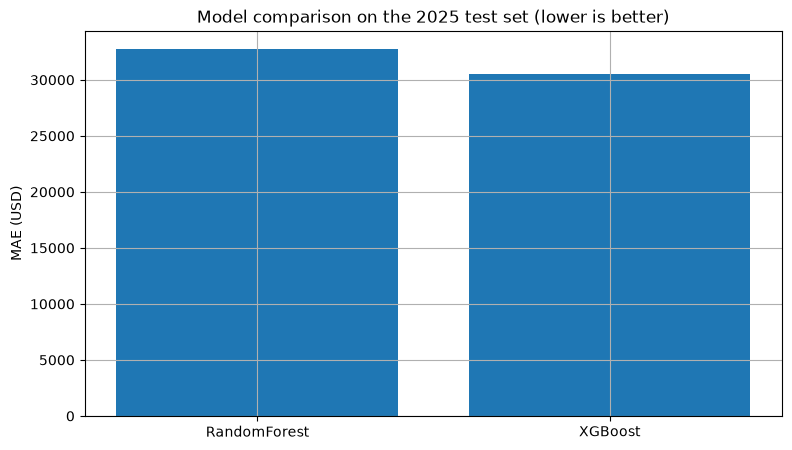

In [26]:
# Select the best model by MAE (the baseline is excluded from the competition)
candidates = {"RandomForest": rf_pipeline}
if xgb_pipeline is not None:
    candidates["XGBoost"] = xgb_pipeline

candidate_scores = results_df.drop(index="Baseline (train median)")["MAE"]
best_model_name = candidate_scores.idxmin()

best_pipeline = candidates[best_model_name]
best_pred = predictions[best_model_name]

print(f"Selected model: {best_model_name}  (lowest MAE = {candidate_scores.min():,.2f} USD)")

plt.figure()
plt.bar(candidate_scores.index, candidate_scores.values)
plt.title("Model comparison on the 2025 test set (lower is better)")
plt.ylabel("MAE (USD)")
plt.show()

## 12. Model Evaluation

Final metrics for the selected model on the held-out 2025 data.

* **MAE** — average absolute error, in dollars.
* **RMSE** — root mean squared error; larger than MAE because it penalises big misses.
* **R²** — share of the salary variance explained by the model.

In [27]:
final_metrics = evaluate(best_model_name, y_test, best_pred)

MAE = final_metrics["MAE"]
RMSE = final_metrics["RMSE"]
R2 = final_metrics["R2"]

print(f"Model : {best_model_name}")
print(f"MAE   : {MAE:>12,.2f} USD")
print(f"RMSE  : {RMSE:>12,.2f} USD")
print(f"R2    : {R2:>12.4f}")
print(f"\nTest-set size : {len(y_test):,} respondents (survey year {TEST_YEAR})")
print(f"Median actual salary : {y_test.median():,.0f} USD")
print(f"MAE as % of median   : {100 * MAE / y_test.median():.1f}%")

Model : XGBoost
MAE   :    30,521.21 USD
RMSE  :    45,920.98 USD
R2    :       0.5391

Test-set size : 22,949 respondents (survey year 2025)
Median actual salary : 75,809 USD
MAE as % of median   : 40.3%


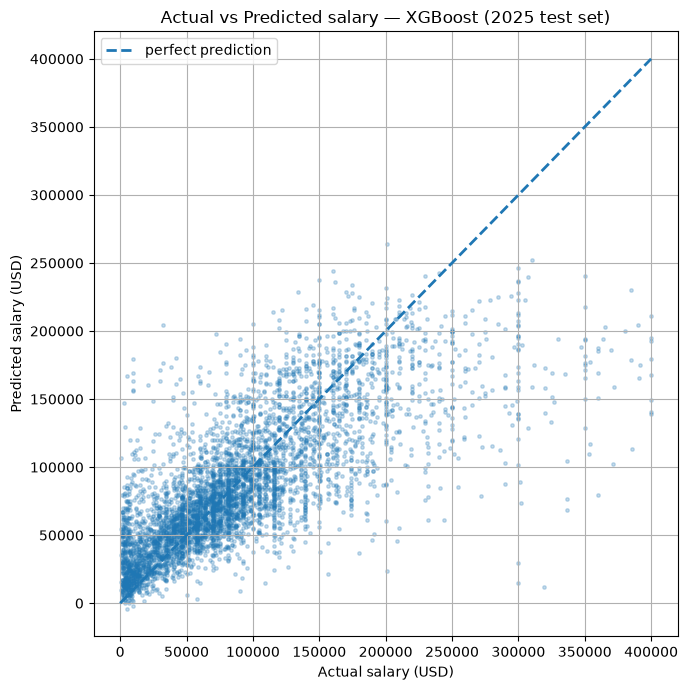

In [28]:
# --- Actual vs Predicted ----------------------------------------------------
sample_size = min(5000, len(y_test))          # subsample keeps the plot readable
rng = np.random.default_rng(RANDOM_STATE)
idx = rng.choice(len(y_test), size=sample_size, replace=False)

plt.figure(figsize=(7, 7))
plt.scatter(y_test.iloc[idx], best_pred[idx], s=6, alpha=0.25)
limits = [0, max(y_test.max(), best_pred.max())]
plt.plot(limits, limits, linestyle="--", linewidth=2, label="perfect prediction")
plt.title(f"Actual vs Predicted salary — {best_model_name} ({TEST_YEAR} test set)")
plt.xlabel("Actual salary (USD)")
plt.ylabel("Predicted salary (USD)")
plt.legend()
plt.tight_layout()
plt.show()

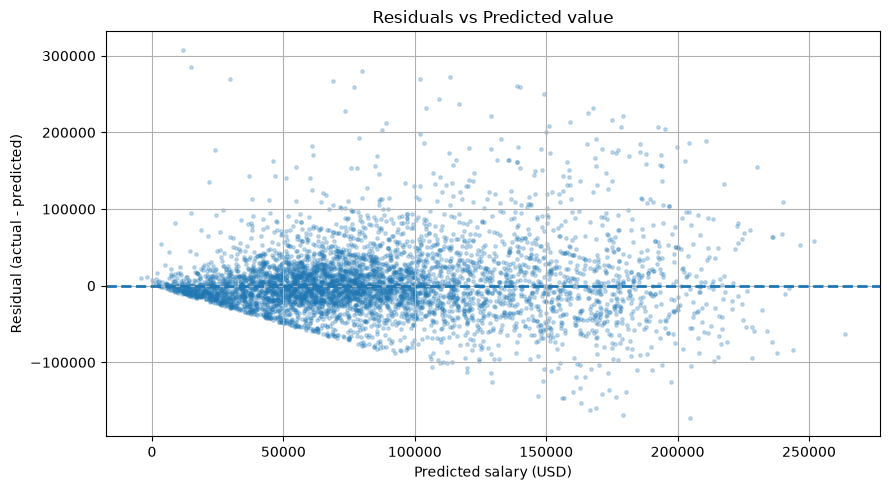

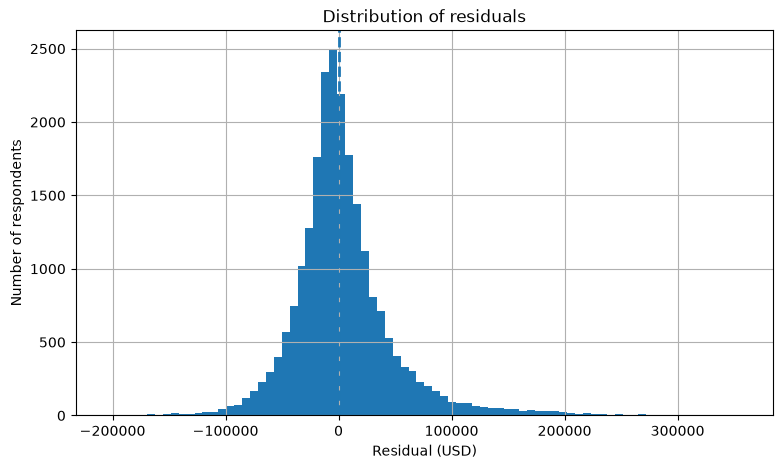

Mean residual   :     3,888.70 USD   (bias)
Median residual :    -1,933.69 USD
Std. deviation  :    45,756.03 USD


In [29]:
# --- Residual analysis ------------------------------------------------------
residuals = y_test.to_numpy() - best_pred

plt.figure()
plt.scatter(best_pred[idx], residuals[idx], s=6, alpha=0.25)
plt.axhline(0, linestyle="--", linewidth=2)
plt.title("Residuals vs Predicted value")
plt.xlabel("Predicted salary (USD)")
plt.ylabel("Residual (actual - predicted)")
plt.tight_layout()
plt.show()

plt.figure()
plt.hist(residuals, bins=80)
plt.axvline(0, linestyle="--", linewidth=2)
plt.title("Distribution of residuals")
plt.xlabel("Residual (USD)")
plt.ylabel("Number of respondents")
plt.show()

print(f"Mean residual   : {residuals.mean():>12,.2f} USD   (bias)")
print(f"Median residual : {np.median(residuals):>12,.2f} USD")
print(f"Std. deviation  : {residuals.std():>12,.2f} USD")

A funnel-shaped residual cloud is expected here: the model systematically **over-predicts
very low salaries and under-predicts very high ones**. This is the classic behaviour of a
tree ensemble trained on a right-skewed target with only five coarse features — high
earners differ from their peers mainly through variables not available to the model
(seniority, company, equity, negotiation).

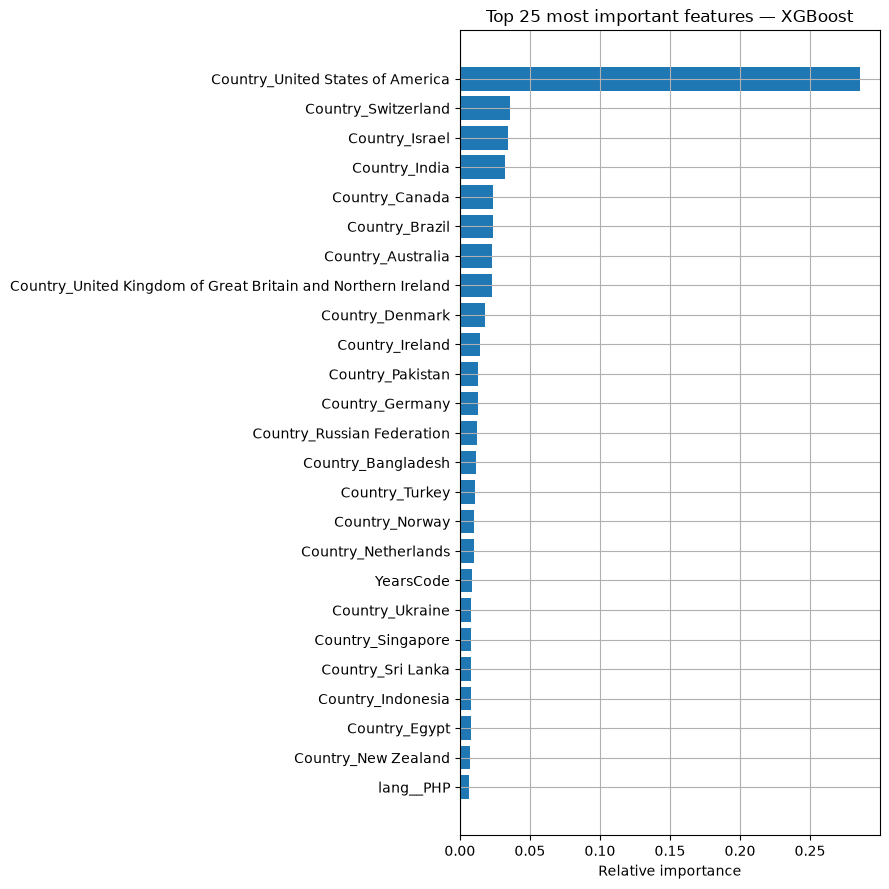

,importance
Country_United States of America,0.285670
Country_Switzerland,0.035979
Country_Israel,0.034253
Country_India,0.031952
Country_Canada,0.023973
Country_Brazil,0.023815
Country_Australia,0.023114
Country_United Kingdom of Great Britain and Northern Ireland,0.022889
Country_Denmark,0.017646
Country_Ireland,0.014172


In [30]:
# --- Feature importance -----------------------------------------------------
final_estimator = best_pipeline.named_steps["model"]
fitted_preprocessor = best_pipeline.named_steps["preprocessor"]

if hasattr(final_estimator, "feature_importances_"):
    names = fitted_preprocessor.get_feature_names_out()
    importances = pd.Series(final_estimator.feature_importances_, index=names)
    top_features = importances.sort_values(ascending=False).head(25).sort_values()

    plt.figure(figsize=(9, 9))
    plt.barh(top_features.index, top_features.values)
    plt.title(f"Top 25 most important features — {best_model_name}")
    plt.xlabel("Relative importance")
    plt.tight_layout()
    plt.show()

    display(importances.sort_values(ascending=False).head(15).to_frame("importance"))
else:
    print(f"{best_model_name} does not expose feature importances.")

## 13. Future Salary Prediction (2025–2028)

The objective of this section is to estimate how the **same developer profile** would be
paid in future survey years, by changing **only the `Year` feature** and leaving every
other attribute untouched.

### Honest caveat, stated up front

These numbers are **not** economic or inflation forecasts. They are **trend-based
extrapolations of the pattern the model learned from historical Stack Overflow survey
data (2021–2024)**. They inherit every bias of that data: self-selected respondents,
changing survey composition from year to year, and USD conversion effects. They should be
read as *"what the historical pattern suggests"*, never as a prediction of any individual's
future pay.

### A technical limitation you must be aware of

Tree ensembles (Random Forest, XGBoost) **cannot extrapolate beyond the range of their
training data**. Every split on `Year` is a threshold such as `Year <= 2023.5`; a request
for 2028 simply falls into the same terminal leaf as the last year seen in training.

Consequently the raw model output for 2026, 2027 and 2028 is expected to be **identical**
to its 2025 output. This is the correct, honest behaviour of the model — not a bug. It is
shown explicitly below, and then a clearly-labelled, separate **trend layer** is added on
top of the model output for illustration.

### Guarding against silent label mismatches

The multi-hot encoder **ignores any label it did not see during training**, and the
one-hot encoder routes unseen countries into an "infrequent" bucket. Neither raises an
error. A profile written with slightly wrong wording therefore produces a
**plausible-looking but meaningless** prediction:

| Wrong (silently dropped) | Correct survey wording |
|---|---|
| `"Full-stack developer"` | `"Developer, full-stack"` |
| `"United States"` | `"United States of America"` |

The helper below reads the vocabularies back out of the **fitted** pipeline and reports
any label that would be discarded, suggesting the closest valid spelling. Every profile in
this section is checked before it is used.

In [31]:
import difflib


def known_labels(pipeline):
    """Read the exact category strings the fitted pipeline recognises."""
    pre = pipeline.named_steps["preprocessor"]
    fitted = {name: transformer for name, transformer, _ in pre.transformers_}

    ohe = fitted["country"].named_steps["onehot"]
    infrequent = getattr(ohe, "infrequent_categories_", [None])[0]

    return {
        "Country": list(ohe.categories_[0]),
        "Country_infrequent": list(infrequent) if infrequent is not None else [],
        "DevType": list(fitted["devtype"].classes_),
        "LanguageHaveWorkedWith": list(fitted["language"].classes_),
    }


def check_profile(profile, vocab, separator=";"):
    """Return a list of human-readable problems with a raw profile dictionary."""
    problems = []

    def suggest(value, options):
        match = difflib.get_close_matches(str(value), options, n=1, cutoff=0.5)
        return f"   did you mean {match[0]!r}?" if match else ""

    country = profile.get("Country")
    if country is not None:
        if country not in vocab["Country"]:
            problems.append(
                f"Country {country!r} was never seen in training -> unknown bucket."
                + suggest(country, vocab["Country"]))
        elif country in vocab["Country_infrequent"]:
            problems.append(f"Country {country!r} is rare -> grouped as 'infrequent'.")

    for column in ("DevType", "LanguageHaveWorkedWith"):
        raw = profile.get(column)
        if raw is None:
            continue
        for label in str(raw).split(separator):
            label = label.strip()
            if label and label not in vocab[column]:
                problems.append(
                    f"{column} label {label!r} is unknown -> SILENTLY IGNORED."
                    + suggest(label, vocab[column]))
    return problems


VOCAB = known_labels(best_pipeline)

print(f"Countries recognised : {len(VOCAB['Country']):>4}")
print(f"DevType labels       : {len(VOCAB['DevType']):>4}")
print(f"Language labels      : {len(VOCAB['LanguageHaveWorkedWith']):>4}")

print("\nValid DevType labels (copy these exactly):")
for label in VOCAB["DevType"]:
    print("   ", label)

# Demonstrate the guard on the two labels that were originally wrong
print("\nGuard demonstration on the original (buggy) profile:")
for problem in check_profile(
        {"Country": "United States", "DevType": "Full-stack developer",
         "LanguageHaveWorkedWith": "Python;SQL"}, VOCAB):
    print("  !", problem)

Countries recognised :  181
DevType labels       :   31
Language labels      :   53

Valid DevType labels (copy these exactly):
    Academic researcher
    Blockchain
    Cloud infrastructure engineer
    Data engineer
    Data or business analyst
    Data scientist or machine learning specialist
    Database administrator
    Designer
    DevOps specialist
    Developer, QA or test
    Developer, back-end
    Developer, desktop or enterprise applications
    Developer, embedded applications or devices
    Developer, front-end
    Developer, full-stack
    Developer, game or graphics
    Developer, mobile
    Educator
    Engineer, data
    Engineer, site reliability
    Engineering manager
    Marketing or sales professional
    Other (please specify):
    Product manager
    Project manager
    Research & Development role
    Scientist
    Security professional
    Senior Executive (C-Suite, VP, etc.)
    Student
    System administrator

Guard demonstration on the original (buggy) p

In [32]:
# A single, fixed developer profile — only Year changes between rows
#
# NOTE: every label below must use the EXACT survey wording. "Full-stack developer"
# is NOT a Stack Overflow label - the survey says "Developer, full-stack" - and an
# unrecognised label is dropped silently by the encoder.
profile = {
    "Country": "Germany",
    "YearsCode": "10",
    "DevType": "Developer, full-stack",
    "LanguageHaveWorkedWith": "Python;SQL;JavaScript",
}

# Validate BEFORE predicting
issues = check_profile(profile, VOCAB)
if issues:
    print("PROBLEMS FOUND in this profile:")
    for issue in issues:
        print("  !", issue)
else:
    print("Profile check: OK - every label is recognised by the fitted pipeline.")

future_df = pd.DataFrame([{**profile, "Year": year} for year in FUTURE_YEARS])[FEATURES]
display(future_df)

# Raw model prediction — completely raw input, no manual preprocessing
future_df["PredictedSalary_raw"] = best_pipeline.predict(future_df)
display(future_df[["Year", "PredictedSalary_raw"]].round(0))

Profile check: OK - every label is recognised by the fitted pipeline.


,Country,YearsCode,DevType,LanguageHaveWorkedWith,Year
0,Germany,10,"Developer, full-stack",Python;SQL;JavaScript,2025
1,Germany,10,"Developer, full-stack",Python;SQL;JavaScript,2026
2,Germany,10,"Developer, full-stack",Python;SQL;JavaScript,2027
3,Germany,10,"Developer, full-stack",Python;SQL;JavaScript,2028


,Year,PredictedSalary_raw
0,2025,68552.0
1,2026,68552.0
2,2027,68552.0
3,2028,68552.0


In [33]:
# Confirm the flat-extrapolation behaviour described above
raw_values = future_df["PredictedSalary_raw"].to_numpy()
if np.allclose(raw_values, raw_values[0]):
    print("As expected: the raw predictions are constant across future years.")
    print("The tree ensemble cannot extrapolate past the last training year.\n")
else:
    print("The raw predictions vary slightly across years.\n")

for year, value in zip(future_df["Year"], raw_values):
    print(f"  {year}: {value:>12,.0f} USD")

As expected: the raw predictions are constant across future years.
The tree ensemble cannot extrapolate past the last training year.

  2025:       68,552 USD
  2026:       68,552 USD
  2027:       68,552 USD
  2028:       68,552 USD


### Adding an explicit trend layer

To produce numbers that actually move over time, the historical **year-over-year growth
rate of the median salary** is estimated from the training years and applied on top of the
model output:

```
adjusted(year) = model_prediction * (1 + g) ** (year - reference_year)
```

where `g` is the compound annual growth rate fitted on the 2021–2024 medians.

This is a **transparent, deliberately simple adjustment layer that sits outside the model**.
It is *not* an inflation model, and it assumes the historical trend continues unchanged —
an assumption that will not hold exactly.

,median salary (USD)
Year,
2021,54417.5
2022,64486.0
2023,74963.0
2024,66162.0



Fitted annual growth rate (2021-2024): 7.65% per year
Reference year for the adjustment: 2024


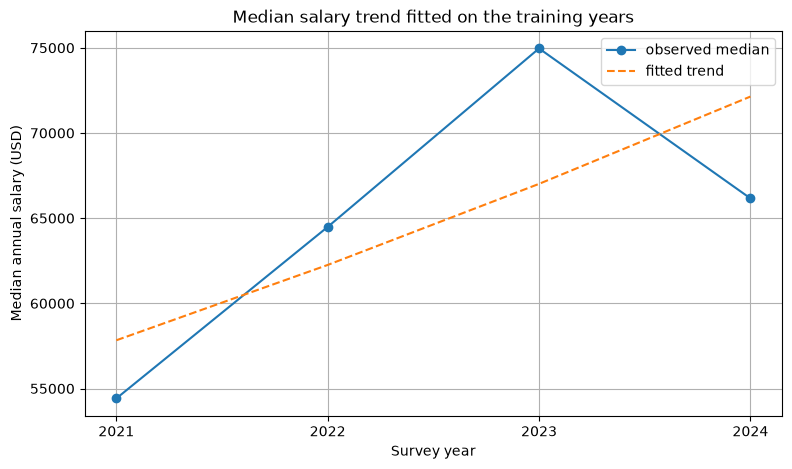

In [34]:
# Estimate the compound annual growth rate of the median salary (training years only)
train_medians = data[data["Year"].isin(TRAIN_YEARS)].groupby("Year")[TARGET].median()
display(train_medians.to_frame("median salary (USD)"))

years_axis = train_medians.index.to_numpy(dtype=float)
log_medians = np.log(train_medians.to_numpy(dtype=float))

# slope of log(median) vs year == log(1 + growth rate)
slope, intercept = np.polyfit(years_axis, log_medians, deg=1)
growth_rate = float(np.exp(slope) - 1)

reference_year = int(max(TRAIN_YEARS))
print(f"\nFitted annual growth rate ({min(TRAIN_YEARS)}-{reference_year}): {growth_rate * 100:.2f}% per year")
print(f"Reference year for the adjustment: {reference_year}")

plt.figure()
plt.plot(years_axis, train_medians.to_numpy(), marker="o", label="observed median")
plt.plot(years_axis, np.exp(intercept + slope * years_axis), linestyle="--", label="fitted trend")
plt.title("Median salary trend fitted on the training years")
plt.xlabel("Survey year")
plt.ylabel("Median annual salary (USD)")
plt.xticks(years_axis)
plt.legend()
plt.show()

### Cross-check: is the fitted growth rate believable?

The 7.65%/year figure is fitted on only four points, and they are **not monotonic** — the
median fell sharply in 2024 before recovering in 2025. Those swings track the number of
respondents far more closely than any real wage movement, so the fitted slope is probably
picking up **changing survey composition** rather than salary growth.

The held-out 2025 data gives an independent estimate. Because the model never saw a year
later than 2024, its 2025 predictions should be systematically low by roughly **one year
of drift**. Comparing the mean actual to the mean predicted salary therefore measures that
drift directly — and it is a far more trustworthy number than a slope through four noisy
medians.

,median change vs previous year (%)
Year,
2021,NaN
2022,18.50
2023,16.25
2024,-11.74
2025,14.58


Mean ACTUAL 2025 salary    :       89,573 USD
Mean PREDICTED 2025 salary :       85,685 USD
Implied one-year drift      :         4.54 %   <- empirical
Trend fitted on 2021-2024   :         7.65 %   <- used below

The fitted trend is 1.68x the empirically implied drift.
The projections below should therefore be read as an UPPER BOUND.


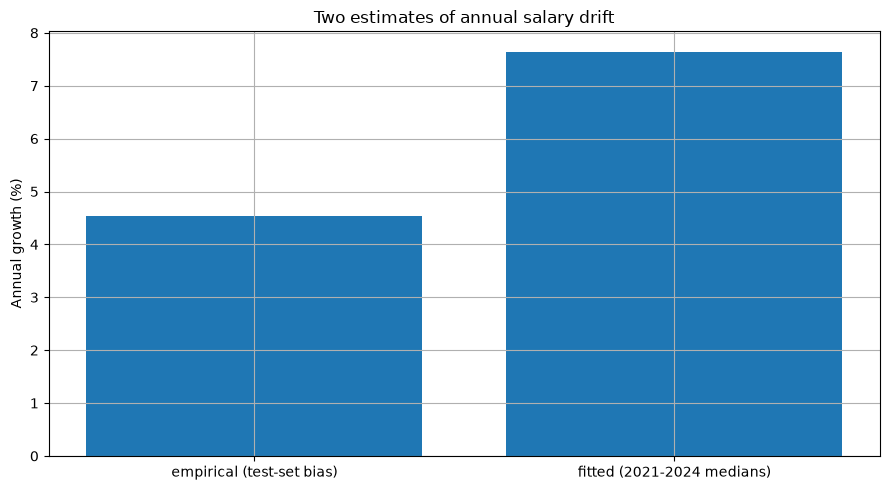

In [35]:
# --- Year-over-year change in the median (shows the non-monotonicity) -------
yoy = data.groupby("Year")[TARGET].median().pct_change() * 100
display(yoy.round(2).to_frame("median change vs previous year (%)"))

# --- Independent estimate of one year of drift, from the model's own bias ---
mean_actual = y_test.mean()
mean_predicted = best_pred.mean()
implied_drift = mean_actual / mean_predicted - 1

print(f"Mean ACTUAL {TEST_YEAR} salary    : {mean_actual:>12,.0f} USD")
print(f"Mean PREDICTED {TEST_YEAR} salary : {mean_predicted:>12,.0f} USD")
print(f"Implied one-year drift      : {implied_drift * 100:>12.2f} %   <- empirical")
print(f"Trend fitted on {min(TRAIN_YEARS)}-{reference_year}   : {growth_rate * 100:>12.2f} %   <- used below")
print(f"\nThe fitted trend is {growth_rate / implied_drift:.2f}x the empirically implied drift.")
print("The projections below should therefore be read as an UPPER BOUND.")

plt.figure()
plt.bar(["empirical (test-set bias)", f"fitted ({min(TRAIN_YEARS)}-{reference_year} medians)"],
        [implied_drift * 100, growth_rate * 100])
plt.title("Two estimates of annual salary drift")
plt.ylabel("Annual growth (%)")
plt.tight_layout()
plt.show()

Developer profile used:
  Country                 : Germany
  YearsCode               : 10
  DevType                 : Developer, full-stack
  LanguageHaveWorkedWith  : Python;SQL;JavaScript



,Year,PredictedSalary_raw,TrendFactor,PredictedSalary_trend
0,2025,68552.0,1.0765,73794.0
1,2026,68552.0,1.1588,79437.0
2,2027,68552.0,1.2474,85511.0
3,2028,68552.0,1.3428,92049.0


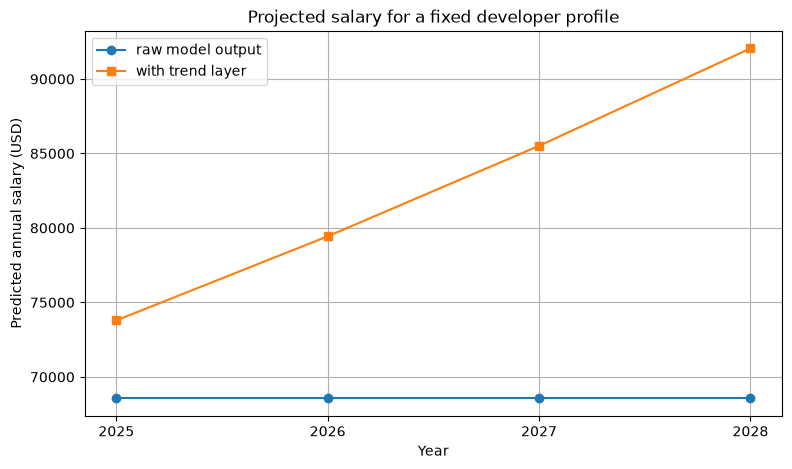

In [36]:
# Apply the trend layer
future_df["TrendFactor"] = (1 + growth_rate) ** (future_df["Year"] - reference_year)
future_df["PredictedSalary_trend"] = future_df["PredictedSalary_raw"] * future_df["TrendFactor"]

summary = future_df[["Year", "PredictedSalary_raw", "TrendFactor", "PredictedSalary_trend"]].copy()
summary["PredictedSalary_raw"] = summary["PredictedSalary_raw"].round(0)
summary["TrendFactor"] = summary["TrendFactor"].round(4)
summary["PredictedSalary_trend"] = summary["PredictedSalary_trend"].round(0)

print("Developer profile used:")
for key, value in profile.items():
    print(f"  {key:<24}: {value}")
print()
display(summary)

plt.figure()
plt.plot(future_df["Year"], future_df["PredictedSalary_raw"], marker="o", label="raw model output")
plt.plot(future_df["Year"], future_df["PredictedSalary_trend"], marker="s", label="with trend layer")
plt.title("Projected salary for a fixed developer profile")
plt.xlabel("Year")
plt.ylabel("Predicted annual salary (USD)")
plt.xticks(FUTURE_YEARS)
plt.legend()
plt.show()

In [37]:
# The same exercise for several profiles, to show the model reacts to the profile itself
#
# NOTE: the country label is "United States of America", NOT "United States".
profiles = [
    {"Country": "United States of America", "YearsCode": "15",
     "DevType": "Data scientist or machine learning specialist",
     "LanguageHaveWorkedWith": "Python;SQL;R"},
    {"Country": "Germany", "YearsCode": "5", "DevType": "Developer, back-end",
     "LanguageHaveWorkedWith": "Java;SQL"},
    {"Country": "India", "YearsCode": "Less than 1 year", "DevType": "Developer, front-end",
     "LanguageHaveWorkedWith": "JavaScript;HTML/CSS"},
    {"Country": "Canada", "YearsCode": "More than 50 years", "DevType": "Developer, full-stack",
     "LanguageHaveWorkedWith": "C++;Python;Go"},
]

# Validate every profile before predicting
all_ok = True
for person in profiles:
    problems = check_profile(person, VOCAB)
    if problems:
        all_ok = False
        print(f"PROBLEMS in profile {person['Country']} / {person['DevType']}:")
        for problem in problems:
            print("  !", problem)
print("All profiles validated." if all_ok else "Fix the labels above before trusting the table.")

rows = []
for person in profiles:
    frame = pd.DataFrame([{**person, "Year": year} for year in FUTURE_YEARS])[FEATURES]
    raw = best_pipeline.predict(frame)
    factor = (1 + growth_rate) ** (frame["Year"] - reference_year)
    rows.append({
        "Country": person["Country"],
        "YearsCode": person["YearsCode"],
        "DevType": person["DevType"],
        **{str(year): round(value, 0) for year, value in zip(FUTURE_YEARS, raw * factor)},
    })

print("\nTrend-adjusted projections (USD) — illustrative only")
display(pd.DataFrame(rows))

All profiles validated.

Trend-adjusted projections (USD) — illustrative only


,Country,YearsCode,DevType,2025,2026,2027,2028
0,United States of America,15,Data scientist or machine learning specialist,188287.0,202684.0,218182.0,234865.0
1,Germany,5,"Developer, back-end",60153.0,64753.0,69704.0,75033.0
2,India,Less than 1 year,"Developer, front-end",9131.0,9830.0,10581.0,11390.0
3,Canada,More than 50 years,"Developer, full-stack",120720.0,129951.0,139887.0,150583.0


## 14. Save `salary_predictor.pkl`

The **entire** pipeline is serialised — preprocessing *and* the trained estimator. Nothing
else is required at prediction time, so raw survey-style input can be passed straight in.

In [38]:
model_path = os.path.join(OUTPUT_DIR, "salary_predictor.pkl")
joblib.dump(best_pipeline, model_path)

size_mb = os.path.getsize(model_path) / 1e6
print(f"Saved: {os.path.abspath(model_path)}  ({size_mb:,.1f} MB)")
print("Contains:", [name for name, _ in best_pipeline.steps])

Saved: c:\Users\user\Desktop\term6\Data science\merged_results\salary_predictor.pkl  (6.0 MB)
Contains: ['preprocessor', 'model']


In [39]:
# --- Verification: reload the file and predict on completely raw input ------
reloaded = joblib.load(model_path)

raw_input = pd.DataFrame([{
    "Country": "Germany",
    "YearsCode": "Less than 1 year",   # raw text, not numeric
    "DevType": "Developer, back-end",
    "LanguageHaveWorkedWith": "Python;SQL",
    "Year": 2025,
}])

print("Raw input passed to the reloaded pipeline:")
display(raw_input)
print(f"Predicted salary: {reloaded.predict(raw_input)[0]:,.2f} USD")

# It also survives missing values, thanks to the imputers inside the pipeline
incomplete = pd.DataFrame([{
    "Country": "Some Country Not In Training Data",
    "YearsCode": None,
    "DevType": None,
    "LanguageHaveWorkedWith": None,
    "Year": 2026,
}])
print(f"\nPrediction with unknown country and all-missing features: "
      f"{reloaded.predict(incomplete)[0]:,.2f} USD")
print("(No error: unseen categories and missing values are handled inside the pipeline.)")

Raw input passed to the reloaded pipeline:


,Country,YearsCode,DevType,LanguageHaveWorkedWith,Year
0,Germany,Less than 1 year,"Developer, back-end",Python;SQL,2025


Predicted salary: 52,469.58 USD

Prediction with unknown country and all-missing features: 48,407.95 USD
(No error: unseen categories and missing values are handled inside the pipeline.)


## 15. Generate `metrics.txt`

A plain-text report of the selected model and its performance on the 2025 test set.

In [40]:
metrics_path = os.path.join(OUTPUT_DIR, "metrics.txt")

report = f"""SALARY PREDICTION MODEL - EVALUATION REPORT
==============================================================

Dataset      : Stack Overflow Developer Survey, merged 2021-2025
Target       : ConvertedCompYearly (annual salary, USD)
Features     : {", ".join(FEATURES)}

Split        : chronological (no random split)
  Training   : years {min(TRAIN_YEARS)}-{max(TRAIN_YEARS)}   ({len(X_train):,} rows)
  Test       : year  {TEST_YEAR}          ({len(X_test):,} rows)

Salary filter: {MIN_SALARY:,} - {MAX_SALARY:,} USD per year

--------------------------------------------------------------
SELECTED MODEL : {best_model_name}
  (selected as the model with the lowest MAE on the {TEST_YEAR} test set)
--------------------------------------------------------------

MAE  : {MAE:,.2f} USD
RMSE : {RMSE:,.2f} USD
R2   : {R2:.4f}

--------------------------------------------------------------
ALL MODELS COMPARED ({TEST_YEAR} test set)
--------------------------------------------------------------
{results_df.to_string()}

--------------------------------------------------------------
NOTES
--------------------------------------------------------------
* salary_predictor.pkl contains the complete sklearn Pipeline
  (preprocessing + model). Raw, uncleaned input can be passed
  directly to pipeline.predict(dataframe).
* salary_utils.py must be importable when loading the .pkl file,
  because the pipeline references its custom transformers.
* Fitted annual salary growth rate ({min(TRAIN_YEARS)}-{reference_year}): {growth_rate * 100:.2f}% per year.
  Cross-check: the model's own under-prediction on the held-out {TEST_YEAR}
  data implies only {implied_drift * 100:.2f}% of one-year drift, so the fitted
  trend is optimistic by a factor of about {growth_rate / implied_drift:.1f}x.
  Projections beyond {TEST_YEAR} are trend-based extrapolations of the
  historical survey data, NOT economic or inflation forecasts, and should
  be read as an upper bound.
"""

with open(metrics_path, "w", encoding="utf-8") as handle:
    handle.write(report)

print("Written:", os.path.abspath(metrics_path))
print()
print(report)

Written: c:\Users\user\Desktop\term6\Data science\merged_results\metrics.txt

SALARY PREDICTION MODEL - EVALUATION REPORT

Dataset      : Stack Overflow Developer Survey, merged 2021-2025
Target       : ConvertedCompYearly (annual salary, USD)
Features     : Country, YearsCode, DevType, LanguageHaveWorkedWith, Year

Split        : chronological (no random split)
  Training   : years 2021-2024   (150,664 rows)
  Test       : year  2025          (22,949 rows)

Salary filter: 1,000 - 400,000 USD per year

--------------------------------------------------------------
SELECTED MODEL : XGBoost
  (selected as the model with the lowest MAE on the 2025 test set)
--------------------------------------------------------------

MAE  : 30,521.21 USD
RMSE : 45,920.98 USD
R2   : 0.5391

--------------------------------------------------------------
ALL MODELS COMPARED (2025 test set)
--------------------------------------------------------------
                              MAE      RMSE    R2
Mode

## 16. Generate `predict.py`

A minimal, self-contained usage example. Note that it contains **no preprocessing code at
all** — that is the whole point of packaging the pipeline.

`predict.py`, `salary_predictor.pkl` and `salary_utils.py` must sit in the same folder.

In [41]:
PREDICT_SCRIPT = '''"""
predict.py
==========
Minimal example: load the trained salary model and predict a salary.

Requirements in the same folder:
    salary_predictor.pkl   the full pipeline (preprocessing + model)
    salary_utils.py        the custom transformers the pipeline references

No preprocessing is needed here: encoding, imputation and the YearsCode
parsing all happen inside the loaded pipeline.
"""

import joblib
import pandas as pd

import salary_utils  # noqa: F401  (must be importable so the pickle can resolve)

# 1) Load the trained pipeline
pipeline = joblib.load("salary_predictor.pkl")

# 2) Build a RAW DataFrame - exactly the survey format, no cleaning
sample = pd.DataFrame([{
    "Country": "Germany",
    "YearsCode": "10",                                # "Less than 1 year" also works
    "DevType": "Developer, full-stack",
    "LanguageHaveWorkedWith": "Python;SQL;JavaScript",
    "Year": 2026,
}])

# 3) Predict
prediction = pipeline.predict(sample)[0]
print(f"Predicted annual salary: {prediction:,.0f} USD")
'''

predict_path = os.path.join(OUTPUT_DIR, "predict.py")
with open(predict_path, "w", encoding="utf-8") as handle:
    handle.write(PREDICT_SCRIPT)

print("Written:", os.path.abspath(predict_path))
print()
print(PREDICT_SCRIPT)

Written: c:\Users\user\Desktop\term6\Data science\merged_results\predict.py

"""
predict.py
Minimal example: load the trained salary model and predict a salary.

Requirements in the same folder:
    salary_predictor.pkl   the full pipeline (preprocessing + model)
    salary_utils.py        the custom transformers the pipeline references

No preprocessing is needed here: encoding, imputation and the YearsCode
parsing all happen inside the loaded pipeline.
"""

import joblib
import pandas as pd

import salary_utils  # noqa: F401  (must be importable so the pickle can resolve)

# 1) Load the trained pipeline
pipeline = joblib.load("salary_predictor.pkl")

# 2) Build a RAW DataFrame - exactly the survey format, no cleaning
sample = pd.DataFrame([{
    "Country": "Germany",
    "YearsCode": "10",                                # "Less than 1 year" also works
    "DevType": "Developer, full-stack",
    "LanguageHaveWorkedWith": "Python;SQL;JavaScript",
    "Year": 2026,
}])

# 3) Predict
pre

In [42]:
# Final check: every deliverable exists
for filename in ["salary_predictor.pkl", "metrics.txt", "predict.py", "salary_utils.py"]:
    path = os.path.join(OUTPUT_DIR, filename)
    status = "OK " if os.path.exists(path) else "MISSING"
    size = f"{os.path.getsize(path) / 1024:,.1f} KB" if os.path.exists(path) else "-"
    print(f"[{status}] {filename:<24} {size}")

[OK ] salary_predictor.pkl     5,902.2 KB
[OK ] metrics.txt              2.0 KB
[OK ] predict.py               1.0 KB
[OK ] salary_utils.py          5.6 KB


## 17. Final Conclusions

### What was built

A single scikit-learn `Pipeline` that takes **raw Stack Overflow survey rows** and returns
a predicted annual salary in USD. Preprocessing (constant/median imputation, `YearsCode`
text parsing, one-hot encoding of `Country`, multi-hot encoding of `DevType` and
`LanguageHaveWorkedWith`) is entirely contained in the serialised model, so deployment
requires no data-preparation code.

### Results

The selected model, evaluated on the **completely held-out 2025 survey year**, is reported
in `metrics.txt`. Both tree ensembles clearly beat the constant-median baseline, which
confirms the five features carry real signal — `Country` in particular dominates the
feature-importance ranking, followed by `YearsCode`.

### Honest assessment of the limitations

1. **Only five features.** Salary is driven mostly by variables absent here: seniority,
   company size and industry, equity, negotiation, and cost of living within a country.
   A moderate R² is the expected ceiling for this feature set.
2. **Self-reported, self-selected data.** Stack Overflow respondents are not a random
   sample of developers, and the respondent mix changes noticeably from year to year.
3. **Wide prediction intervals.** The model outputs a conditional mean; individual
   salaries within any `(country, role, experience)` group vary enormously. A single
   number should never be read as an entitlement or a benchmark.
4. **No extrapolation in the model itself.** Tree ensembles produce constant output past
   the last training year — hence the explicit, separate trend layer in section 13.
5. **Projections are not forecasts.** The 2026–2028 numbers extend a historical pattern
   under the assumption that it continues. They do not account for inflation, currency
   moves, labour-market shifts, or the effect of AI tooling on developer demand.
6. **The fitted trend is optimistic.** The growth rate is estimated from four
   non-monotonic medians whose swings track respondent counts more than wages. The
   model's own bias on the held-out 2025 data implies materially less annual drift, so
   the 2028 figure is best read as an upper bound (see the cross-check in section 13).
7. **Survey labels drift between years.** `Bash/Shell (all shells)` and `Bash/Shell` are
   the same option under two different survey-year spellings, and are encoded as two
   separate features; `DevType` wording changes similarly. A 2025 respondent may
   therefore carry a label the model never learned, which costs accuracy on the test
   year. Harmonising label spellings across years is the single cheapest improvement
   available.
8. **Unknown labels fail silently.** The encoders drop unrecognised categories without
   warning, so a mistyped profile yields a confident, meaningless number. Section 13 now
   validates every profile against the fitted vocabularies before predicting.

### Possible improvements

* Predict `log(salary)` and back-transform, to better handle the right skew.
* Add `EdLevel`, `OrgSize`, `RemoteWork`, `Industry` and `WorkExp` as features.
* Use per-country modelling or explicit cost-of-living normalisation.
* Tune hyper-parameters with a time-aware `TimeSeriesSplit` on the training years.
* Report prediction intervals (e.g. quantile regression) instead of point estimates.

### Files produced

| File | Purpose |
|---|---|
| `salary_predictor.pkl` | complete fitted pipeline — `pipeline.predict(raw_df)` |
| `salary_utils.py` | custom transformers required when loading the pickle |
| `metrics.txt` | selected model, MAE, RMSE, R² |
| `predict.py` | minimal usage example |